Importing Neccessary libraries

In [ ]:
 import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

In [ ]:

# Define the path to your dataset
dataset_path = '/content/drive/My Drive/colon cancer'  # Change this to your dataset path


In [ ]:
dataset_path = '/content/drive/My Drive/colon cancer'


pre-processing and loading


In [ ]:
# Initialize lists to hold images and labels
images = []
labels = []

# Loop through each class folder
for class_name in os.listdir(dataset_path):
    class_folder = os.path.join(dataset_path, class_name)

    # Check if it is a directory
    if os.path.isdir(class_folder):
        for img_name in os.listdir(class_folder):
            img_path = os.path.join(class_folder, img_name)

            # Check if it's a file (and not a subdirectory)
            if os.path.isfile(img_path):
                # Load the image
                img = Image.open(img_path)
                img = img.resize((64, 64))  # Resize to a fixed size
                img_array = np.array(img)

                # Append to lists
                images.append(img_array)
                labels.append(class_name)

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)




In [ ]:
print(images)

[]


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

# Navigate to your dataset folder in Google Drive
import os
data_dir = '/content/drive/My Drive/colon cancer'


In [ ]:
import os
import glob

In [ ]:
# Traverse through the nested directories
for class_dir in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_dir)
    if os.path.isdir(class_path):
        for sub_folder in os.listdir(class_path):
            sub_folder_path = os.path.join(class_path, sub_folder)
            if os.path.isdir(sub_folder_path):
                # Get all image files in the sub-folder
                for image_file in glob.glob(os.path.join(sub_folder_path, "*.png")):  # Modify extension if different
                    image_paths.append(image_file)
                    labels.append(class_dir)  # Append the class label



In [ ]:
import os
import glob
import numpy as np

In [ ]:
# Initialize an empty list to store image paths
image_paths = []
# Traverse through the nested directories
for class_dir in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_dir)
    if os.path.isdir(class_path):
        print(f"Processing class: {class_dir}")
        for sub_folder in os.listdir(class_path):
            sub_folder_path = os.path.join(class_path, sub_folder)
            if os.path.isdir(sub_folder_path):
                print(f"  Sub-folder: {sub_folder}")
                # Get all image files in the sub-folder
                images_found = glob.glob(os.path.join(sub_folder_path, "*.jpg"))  # Modify extension if different
                print(f"    Found {len(images_found)} images")
                for image_file in images_found:
                    image_paths.append(image_file)



# Initialize empty lists for image paths and labels
image_paths = []
labels = []

# Traverse through the nested directories
for class_dir in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_dir)
    if os.path.isdir(class_path):
        print(f"Processing class: {class_dir}")

        # Recursively search for images in all subdirectories
        for image_file in glob.glob(os.path.join(class_path, "**", "*.jpg"), recursive=True):  # Match .jpg files
            if os.path.isfile(image_file):  # Ensure it's a file, not a directory
                image_paths.append(image_file)  # Append image path to list
                labels.append(class_dir)  # Append class label

        print(f"  Found {len(image_paths)} images in class: {class_dir}")

print(f"Total images: {len(image_paths)}")

# After appending all image paths, convert to NumPy array (if needed)
import numpy as np
image_paths = np.array(image_paths)
labels = np.array(labels)


Processing class: ulcerative-colitis
  Sub-folder: ulcerative-colitis
    Found 1001 images
Processing class: normal-pylorus
  Sub-folder: normal-pylorus
    Found 1000 images
Processing class: normal-z-line
  Sub-folder: normal-z-line
    Found 1001 images
Processing class: dyed-resection-margins
  Sub-folder: dyed-resection-margins
    Found 1005 images
Processing class: esophagitis
  Sub-folder: esophagitis
    Found 1007 images
Processing class: polyps
  Sub-folder: polyps
    Found 1000 images
Processing class: dyed-lifted-polyps
  Sub-folder: dyed-lifted-polyps
    Found 1010 images
Processing class: normal-cecum
  Sub-folder: normal-cecum
    Found 1016 images
Processing class: ulcerative-colitis
  Found 1001 images in class: ulcerative-colitis
Processing class: normal-pylorus
  Found 2001 images in class: normal-pylorus
Processing class: normal-z-line
  Found 3002 images in class: normal-z-line
Processing class: dyed-resection-margins
  Found 4007 images in class: dyed-resectio

In [ ]:
print(images_found)

['/content/drive/My Drive/colon cancer/normal-cecum/normal-cecum/0ecc75ff-be06-4183-a729-174dbef6054a.jpg', '/content/drive/My Drive/colon cancer/normal-cecum/normal-cecum/080f65da-aa22-4663-8923-3f4da73c6dca.jpg', '/content/drive/My Drive/colon cancer/normal-cecum/normal-cecum/03eb7061-0329-405a-a4b6-d629cf01baad.jpg', '/content/drive/My Drive/colon cancer/normal-cecum/normal-cecum/02b728cd-f151-44ba-8014-b7772949eb15.jpg', '/content/drive/My Drive/colon cancer/normal-cecum/normal-cecum/10e5fafc-20e7-4792-a90b-f4c0ff278f30.jpg', '/content/drive/My Drive/colon cancer/normal-cecum/normal-cecum/0caa503d-9303-4979-a649-3d4cfc1ef2c1.jpg', '/content/drive/My Drive/colon cancer/normal-cecum/normal-cecum/02dcedf1-c0bd-4ef4-b072-ea8f11da6a1d.jpg', '/content/drive/My Drive/colon cancer/normal-cecum/normal-cecum/01e023db-5c76-4c28-91ab-06e36cd31495.jpg', '/content/drive/My Drive/colon cancer/normal-cecum/normal-cecum/096174d5-24ca-40e3-8fff-7feb3f74f0ac.jpg', '/content/drive/My Drive/colon cance

In [ ]:
#model selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_curve,roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder

Copying Dataset Files

In [ ]:
import os
import shutil

In [ ]:
# Paths for the dataset in Google Drive and the destination directory in Colab
root_dir = "/content/drive/My Drive/colon cancer"  # Update this with the actual path
dest_directory = "/content/dataset"

# Create destination directory if it doesn't exist
if not os.path.exists(dest_directory):
    os.mkdir(dest_directory)

# Iterate through directories and copy files
for directory in os.listdir(root_dir):
    dir_path = os.path.join(root_dir, directory)
    destination = os.path.join(dest_directory, directory)

    # Create sub-directory if it doesn't exist
    if not os.path.exists(destination):
        os.mkdir(destination)

    for directory2 in os.listdir(dir_path):
        dir_path2 = os.path.join(dir_path, directory2)
        for image in os.listdir(dir_path2):
            image_path = os.path.join(dir_path2, image)
            dest_path = os.path.join(destination, image)

            # Avoid overwriting files
            if not os.path.exists(dest_path):
                shutil.copy(image_path, dest_path)

print(f"Dataset copied to {dest_directory}")

Dataset copied to /content/dataset


In [ ]:
import tensorflow as tf
tf.config.list_physical_devices(
    device_type=None
)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Creating TensorFlow Datasets

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras import Sequential

from tensorflow.keras.layers import Dense, Dropout

from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score


import warnings
warnings.filterwarnings("ignore")

tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

# Define paths
dataset_path = "/content/dataset"  # Adjust this path to your dataset location
image_size = (224, 224)
batch_size = 64

# Ensure the dataset path exists
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset directory does not exist: {dataset_path}")

# Create training and validation datasets
try:
    train_ds = image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        label_mode="categorical",
        seed=23,
        image_size=image_size,
        batch_size=batch_size,
    )

    val_ds = image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        label_mode="categorical",
        seed=23,
        image_size=image_size,
        batch_size=batch_size,
    )

    print("Training and validation datasets created successfully.")

except Exception as e:
    print(f"An error occurred: {e}")

Found 8040 files belonging to 8 classes.
Using 6432 files for training.
Found 8040 files belonging to 8 classes.
Using 1608 files for validation.
Training and validation datasets created successfully.


In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.18.0


In [ ]:
pip install --upgrade numpy protobuf keras tensorflow-datasets


  Using cached protobuf-6.30.2-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)


In [ ]:
class_names = train_ds.class_names

In [ ]:
# Returns the cardinality of the data
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Model Definition and Compilation

In [ ]:
model = Sequential()
base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    pooling='avg',
    classifier_activation="softmax",
)

for layer in base_model.layers:
        layer.trainable=True
model.add(base_model)
model.add(Flatten())
model.add(Dense(8, activation='softmax'))

model.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=0.004, beta_1=0.9, beta_2=0.999, epsilon=1e-8),
          loss=CategoricalCrossentropy(),
          metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
import os

# Ensure the directory exists
os.makedirs("training_weights/best", exist_ok=True)

# Learning rate reduction
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-5
)

# Model checkpoint
best = ModelCheckpoint(
    filepath="training_weights/best/model_best_val_accuracy.weights.h5",  # Corrected file extension
    save_weights_only=True,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20
)

print("Callbacks defined successfully.")



Callbacks defined successfully.


model train

In [ ]:
model.fit(train_ds, epochs=100, validation_data=val_ds, callbacks=[reduce_lr, best,])

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.7749 - loss: 0.6192 - val_accuracy: 0.9201 - val_loss: 0.2209 - learning_rate: 0.0010
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 97s 748ms/step - accuracy: 0.9103 - loss: 0.2435 - val_accuracy: 0.9034 - val_loss: 0.3205 - learning_rate: 0.0010
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 84s 769ms/step - accuracy: 0.9394 - loss: 0.1716 - val_accuracy: 0.9214 - val_loss: 0.2360 - learning_rate: 0.0010
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 74s 733ms/step - accuracy: 0.9635 - loss: 0.0997 - val_accuracy: 0.8711 - val_loss: 0.3593 - learning_rate: 0.0010
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 78s 766ms/step - accuracy: 0.9717 - loss: 0.0850 - val_accuracy: 0.9356 - val_loss: 0.2767 - learning_rate: 0.0010
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 80s 751ms/step - accuracy: 0.9812 - loss: 0.0591 - val_accuracy: 0.9356 - val_loss: 0.1965 - learning_rate: 0.0010
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 84s 769ms/step - accuracy

In [ ]:
model.save('my_model.keras')

In [ ]:
history = model.history

In [ ]:
loss = history.history['loss'] + history.history['loss']
val_loss = history.history['val_loss'] + history.history['val_loss']
accuracy = history.history['accuracy'] + history.history['accuracy']
val_accuracy = history.history['val_accuracy'] + history.history['val_accuracy']

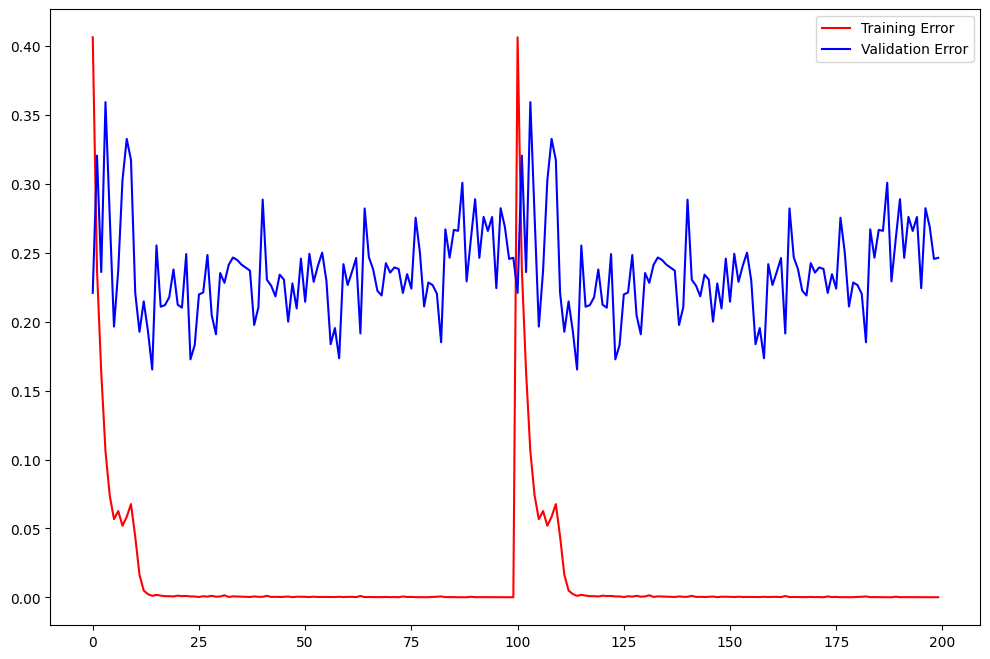

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(loss,color='r',label='Training Error')
plt.plot(val_loss, color='b',label='Validation Error')
plt.legend()
plt.show()

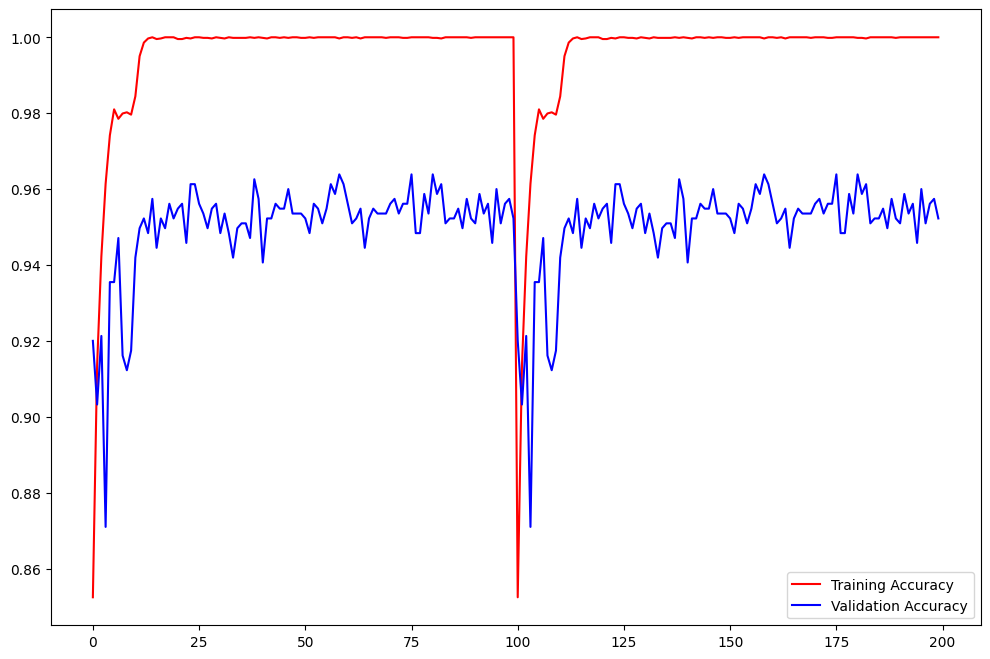

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(accuracy,color='r',label='Training Accuracy')
plt.plot(val_accuracy, color='b',label='Validation Accuracy')
plt.legend()
plt.show()

Evaluation and Visualization

In [ ]:
true_labels = []
predicted_labels = []

# Iterate through test dataset to get true labels
for images, labels in test_ds:
    true_labels.extend(np.argmax(labels.numpy(), axis=1))  # Assuming one-hot encoded labels

    # Predict labels using the model
    predictions = model.predict(images)
    predicted_labels.extend(np.argmax(predictions, axis=1))

# Convert lists to NumPy arrays for easier processing
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


In [ ]:
accuracy = accuracy_score(true_labels, predicted_labels)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.95


In [ ]:
cm = confusion_matrix(true_labels, predicted_labels)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 83   4   0   0   0   0   1   0]
 [  1  89   0   0   0   0   0   0]
 [  0   0  91   0   0  12   0   0]
 [  0   0   0 105   0   0   0   0]
 [  0   0   0   0 105   0   0   0]
 [  0   0  11   0   0 108   0   0]
 [  1   0   0   1   1   0  99   1]
 [  0   0   2   1   0   0   2 114]]


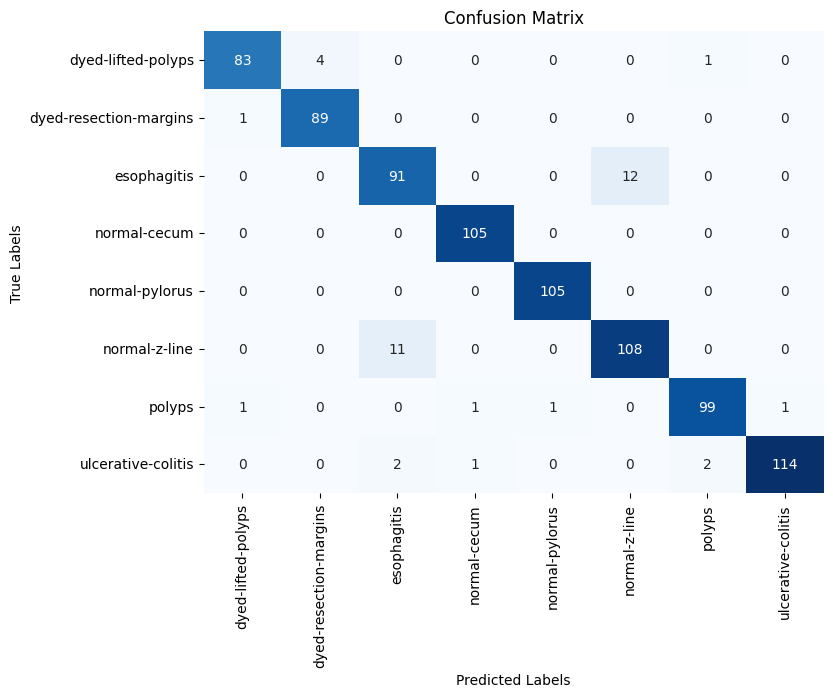

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()